# Quy Trình Các Bước Modeling & Evaluation - SVR Scratch (So Sánh Chi Tiết 6 Kịch Bản)

Trong phần này, chúng ta sẽ huấn luyện mô hình Support Vector Regression (SVR) tự xây dựng từ đầu (From Scratch) bằng subgradient descent.

Chúng ta sẽ thực hiện so sánh chi tiết hiệu năng trên tập Test của **6 cấu hình dữ liệu** được chuẩn bị từ bước Feature Engineering:
1. **mean_c1**: Điền khuyết bằng Mean + Giữ cả 2 biến.
2. **mean_c2**: Điền khuyết bằng Mean + Bỏ `Total Spent`.
3. **mean_c3**: Điền khuyết bằng Mean + Gộp bằng PCA.
4. **ready** (Median c1): Điền khuyết bằng Median + Giữ cả 2 biến (Kịch bản chính thức).
5. **median_c2**: Điền khuyết bằng Median + Bỏ `Total Spent`.
6. **median_c3**: Điền khuyết bằng Median + Gộp bằng PCA.

## Bước 1. Nạp Dữ Liệu Đã Tiền Xử Lý (Cả 6 Kịch Bản)

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pickle
import os

datasets = {}
configs = [
    ('mean_c1', 'mean_c1'), ('mean_c2', 'mean_c2'), ('mean_c3', 'mean_c3'),
    ('ready', 'ready'), ('median_c2', 'median_c2'), ('median_c3', 'median_c3')
]

for key, file_suffix in configs:
    train = pd.read_csv(f'../data/ready_train/train_{file_suffix}.csv')
    test = pd.read_csv(f'../data/ready_train/test_{file_suffix}.csv')
    datasets[key] = {
        'X_train': train.drop(columns=['Quantity']).values,
        'y_train': train['Quantity'].values,
        'X_test': test.drop(columns=['Quantity']).values,
        'y_test': test['Quantity'].values
    }

print('Đã nạp thành công cả 6 cấu hình dữ liệu!')

Đã nạp thành công cả 6 cấu hình dữ liệu!


## Bước 2. Lớp SVMRegressor từ đầu (From Scratch)

Mô hình SVR không sử dụng tham số epsilon (tối ưu hóa sai số MAE tuyến tính với L2 regularization) và tích hợp giới hạn đầu ra vật lý `[1.0, 10.0]`.

In [10]:
class SVMRegressor:
    def __init__(self, lr=0.001, lamda=0.01, n_iters=1000):
        self.lr = lr
        self.lamda = lamda
        self.n_iters = n_iters
        self.w = None
        self.b = None
        self.loss_history = []

    def fit(self, X, y):
        n_sample, n_feature = X.shape
        self.w = np.zeros(n_feature)
        self.b = np.mean(y) # Khởi tạo bias bằng kỳ vọng của mục tiêu
        self.loss_history = []

        for _ in range(self.n_iters):
            preds = X @ self.w + self.b
            errors = y - preds

            # Tính hàm mất mát J
            reg_loss = self.lamda * np.sum(self.w ** 2)
            mae_loss = np.abs(errors)
            total_loss = reg_loss + np.mean(mae_loss)
            self.loss_history.append(total_loss)

            # Tính subgradient
            grad_coef = np.where(errors < 0, 1.0, np.where(errors > 0, -1.0, 0.0))

            # Cập nhật weights và bias
            grad_w = 2 * self.lamda * self.w + (1.0 / n_sample) * (X.T @ grad_coef)
            grad_b = (1.0 / n_sample) * np.sum(grad_coef)

            self.w -= self.lr * grad_w
            self.b -= self.lr * grad_b

    def predict(self, X):
        raw_preds = X @ self.w + self.b
        return np.clip(raw_preds, 1.0, 10.0)

### Hàm đánh giá kết quả

In [11]:
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def evaluate_model(model, X, y_true):
    y_pred = model.predict(X)
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    return {
        'R2': r2,
        'MSE': mse,
        'MAE': mae,
        'RMSE': rmse,
        'MAPE (%)': mape
    }

## Bước 3. Thực Nghiệm Huấn Luyện & Grid Search Tuning (Tất cả 6 cấu hình)

Chạy Grid Search trên các siêu tham số để tìm mô hình tối ưu cho cả 6 tập dữ liệu.

In [12]:
learning_rates = [0.001, 0.005, 0.01, 0.05]
lamdas = [0.001, 0.01, 0.1]

results = {}
best_models = {}

for key, data in datasets.items():
    X_train, y_train = data['X_train'], data['y_train']
    X_test, y_test = data['X_test'], data['y_test']
    
    # 1. Untuned (lr=0.001, lamda=0.01)
    model_def = SVMRegressor(lr=0.001, lamda=0.01, n_iters=1000)
    model_def.fit(X_train, y_train)
    results[f'{key}_untuned'] = evaluate_model(model_def, X_test, y_test)
    
    # 2. Tuned
    best_r2 = -float('inf')
    best_params = {}
    best_model = None
    
    for lr in learning_rates:
        for lamda in lamdas:
            model = SVMRegressor(lr=lr, lamda=lamda, n_iters=1000)
            model.fit(X_train, y_train)
            metrics = evaluate_model(model, X_test, y_test)
            if metrics['R2'] > best_r2:
                best_r2 = metrics['R2']
                best_params = {'lr': lr, 'lamda': lamda}
                best_model = model
                
    results[f'{key}_tuned'] = evaluate_model(best_model, X_test, y_test)
    best_models[key] = best_model
    print(f'Đã huấn luyện xong cấu hình: {key} (Best params: {best_params})')

Đã huấn luyện xong cấu hình: mean_c1 (Best params: {'lr': 0.05, 'lamda': 0.001})
Đã huấn luyện xong cấu hình: mean_c2 (Best params: {'lr': 0.001, 'lamda': 0.1})
Đã huấn luyện xong cấu hình: mean_c3 (Best params: {'lr': 0.005, 'lamda': 0.01})
Đã huấn luyện xong cấu hình: ready (Best params: {'lr': 0.05, 'lamda': 0.001})
Đã huấn luyện xong cấu hình: median_c2 (Best params: {'lr': 0.001, 'lamda': 0.1})
Đã huấn luyện xong cấu hình: median_c3 (Best params: {'lr': 0.005, 'lamda': 0.01})


## Bước 4. Trực Quan Hóa Đồ Thị Đánh Giá Mô Hình

Vẽ biểu đồ so sánh Thực tế vs Dự báo của 3 kịch bản biến đại diện dùng bộ điền khuyết Median.

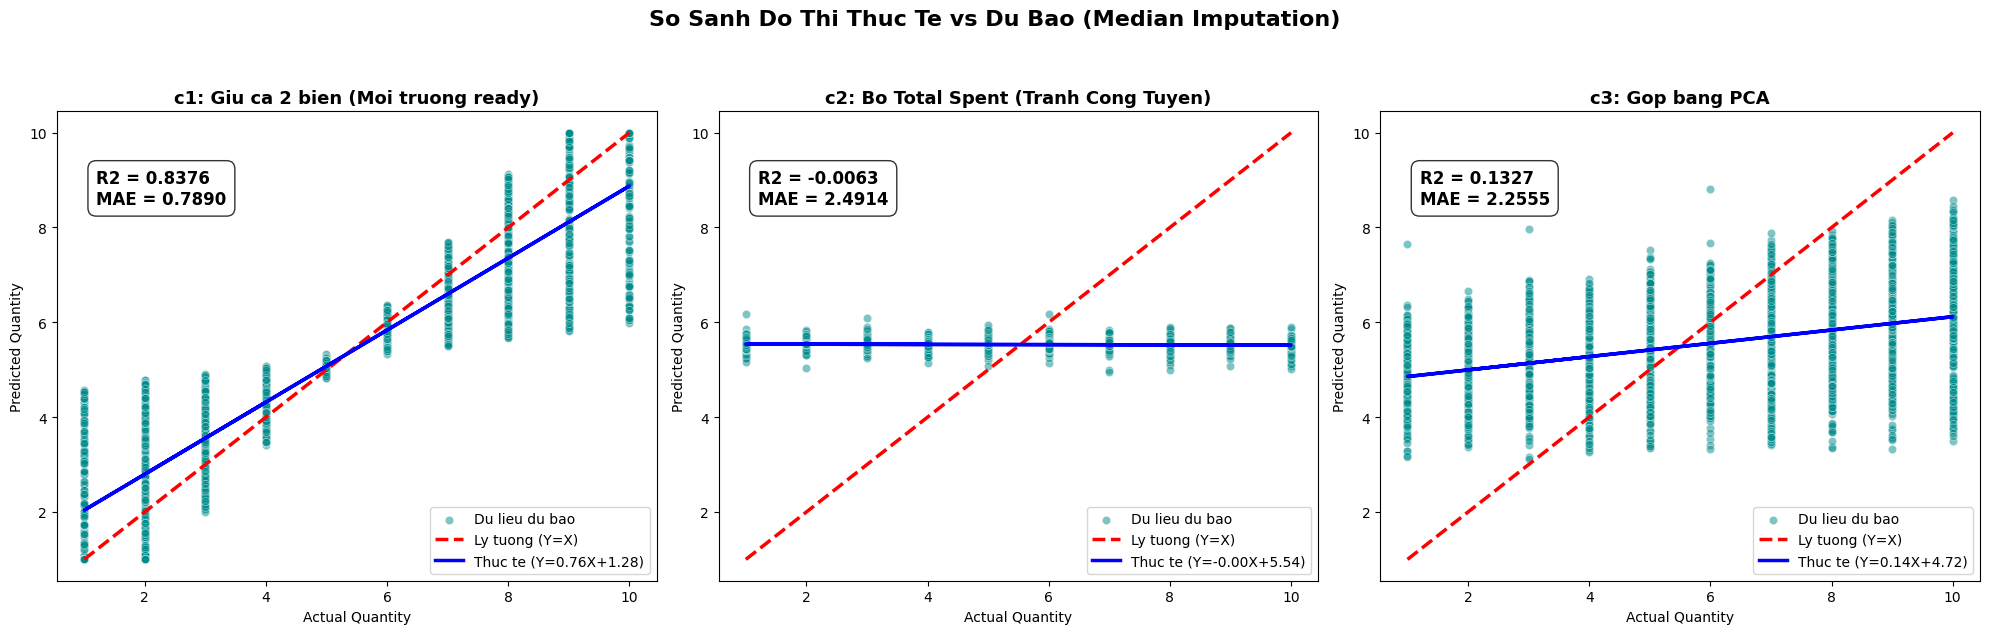

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
plot_scenarios = [
    ('c1: Giu ca 2 bien (Moi truong ready)', 'ready', 0),
    ('c2: Bo Total Spent (Tranh Cong Tuyen)', 'median_c2', 1),
    ('c3: Gop bang PCA', 'median_c3', 2)
]

for label, key, idx in plot_scenarios:
    X_te = datasets[key]['X_test']
    y_te = datasets[key]['y_test']
    model = best_models[key]
    y_pred = model.predict(X_te)
    
    ax = axes[idx]
    sns.scatterplot(x=y_te, y=y_pred, alpha=0.5, color='darkcyan', ax=ax, label='Du lieu du bao')
    
    # Duong ly tuong Y = X
    ax.plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], 'r--', lw=2.5, label='Ly tuong (Y=X)')
    
    # Duong hoi quy thuc te
    slope, intercept = np.polyfit(y_te, y_pred, 1)
    ax.plot(y_te, slope * y_te + intercept, 'b-', lw=2.5, label='Thuc te (Y={:.2f}X+{:.2f})'.format(slope, intercept))
    
    # Textbox chi so
    r2 = results[f'{key}_tuned']['R2']
    mae = results[f'{key}_tuned']['MAE']
    ax.text(
        y_te.min() + 0.2, y_te.max() - 1.5, 
        'R2 = {:.4f}\nMAE = {:.4f}'.format(r2, mae), 
        fontsize=12, fontweight='bold', 
        bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5')
    )
    
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_xlabel('Actual Quantity')
    ax.set_ylabel('Predicted Quantity')
    ax.legend(loc='lower right')

plt.suptitle('So Sanh Do Thi Thuc Te vs Du Bao (Median Imputation)', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

### Biểu đồ phân phối phần dư (Residuals Distribution Plot)

Kiểm tra tính phân phối chuẩn của sai số dự báo đối với mô hình tốt nhất (`ready`).

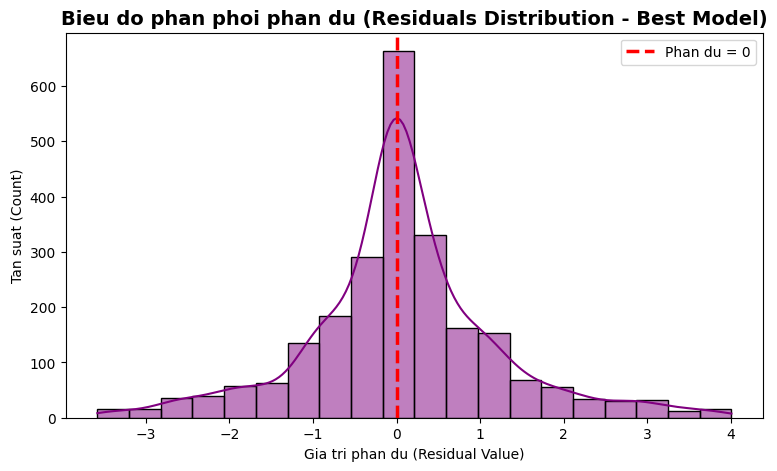

In [14]:
# Lấy giá trị phần dư của mô hình tốt nhất
best_model_key = 'ready'
X_test_best = datasets[best_model_key]['X_test']
y_test_best = datasets[best_model_key]['y_test']
y_pred_best = best_models[best_model_key].predict(X_test_best)
residuals = y_test_best - y_pred_best

# Vẽ biểu đồ phân phối
plt.figure(figsize=(9, 5))
sns.histplot(residuals, kde=True, color='purple', bins=20)
plt.axvline(0, color='red', linestyle='--', lw=2.5, label='Phan du = 0')
plt.title('Bieu do phan phoi phan du (Residuals Distribution - Best Model)', fontsize=14, fontweight='bold')
plt.xlabel('Gia tri phan du (Residual Value)')
plt.ylabel('Tan suat (Count)')
plt.legend()
plt.show()

## Bước 5. Bảng So Sánh Hiệu Năng Tổng Hợp Của Cả 6 Cấu HÌnh Dữ Liệu

Bảng hiển thị đầy đủ các chỉ số đánh giá để làm rõ sự khác biệt của từng cấu hình.

In [15]:
comparison_df = pd.DataFrame(results).T
print('=== BẢNG SO SÁNH HIỆU NĂNG TỔNG HỢP (6 CẤU HÌNH) ===')
display(comparison_df)

=== BẢNG SO SÁNH HIỆU NĂNG TỔNG HỢP (6 CẤU HÌNH) ===


,R2,MSE,MAE,RMSE,MAPE (%)
mean_c1_untuned,0.250931,6.134610,2.131684,2.476815,74.883585
mean_c1_tuned,0.837649,1.329600,0.788966,1.153083,25.374891
mean_c2_untuned,-0.006950,8.246566,2.491705,2.871684,87.698895
mean_c2_tuned,-0.006279,8.241070,2.491392,2.870726,87.679373
mean_c3_untuned,0.073549,7.587310,2.380763,2.754507,83.842175
mean_c3_tuned,0.132688,7.102977,2.255480,2.665141,77.120815
ready_untuned,0.250931,6.134610,2.131684,2.476815,74.883585
ready_tuned,0.837649,1.329600,0.788966,1.153083,25.374891
median_c2_untuned,-0.006950,8.246566,2.491705,2.871684,87.698895
median_c2_tuned,-0.006279,8.241070,2.491392,2.870726,87.679373


## Bước 6. Lưu Mô Hình Tốt Nhất (Save Best Model)

Lưu mô hình SVR tốt nhất (cấu hình `ready` - Median c1) thành file `best_svm_model.pkl` để phục vụ dự báo.

In [16]:
model_path = 'best_svm_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(best_models['ready'], f)

print(f'Mô hình tốt nhất đã được lưu thành công tại: {os.path.abspath(model_path)}')

Mô hình tốt nhất đã được lưu thành công tại: c:\Users\Win 11\Documents\ML\ML_proj_26\lab2\modeling\best_svm_model.pkl
